In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

In [2]:
#upload the data file 
air_df = pd.read_csv('Air_Quality.csv') 
conn=sqlite3.connect('Air_Quality.csv') 
#check that it was uploaded 
air_df.head(n = 3) 

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN


In [3]:
#check the column names 
air_df.columns 

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [4]:
#Change data types 
air_df['Unique ID'].apply(int) 
air_df['Indicator ID'].apply(int) 
air_df['Name'].apply(str) 
air_df['Measure'].apply(str) 
air_df['Measure Info'].apply(str) 
air_df['Geo Type Name'].apply(str) 
air_df['Geo Join ID'].apply(int) 
air_df['Geo Place Name'].apply(str) 
air_df['Time Period'].apply(str) 
air_df['Data Value'].apply(float)

0        23.97
1        27.42
2        12.55
3        22.63
4        14.00
         ...  
18857    25.78
18858    28.13
18859    28.78
18860    23.68
18861    23.77
Name: Data Value, Length: 18862, dtype: float64

In [5]:
#convert start_date column to date format
#may need to do this for every new dataframe as needed - need to test
air_df['Start_Date'] = pd.to_datetime(air_df['Start_Date'])

In [6]:
#look for invalid values 
invalidmask = air_df.astype(str).applymap(lambda x: bool(re.search(r'[^ -~]', x))) 
dirty_rows=air_df[invalidmask.any(axis=1)]
print(dirty_rows) 

       Unique ID  Indicator ID                               Name  \
7546      799850           647  Outdoor Air Toxics - Formaldehyde   
7547      315663           647  Outdoor Air Toxics - Formaldehyde   
7548      315673           647  Outdoor Air Toxics - Formaldehyde   
7549      130767           647  Outdoor Air Toxics - Formaldehyde   
7550      130739           647  Outdoor Air Toxics - Formaldehyde   
...          ...           ...                                ...   
18685     130764           647  Outdoor Air Toxics - Formaldehyde   
18686     799867           647  Outdoor Air Toxics - Formaldehyde   
18687     315641           647  Outdoor Air Toxics - Formaldehyde   
18777     130780           647  Outdoor Air Toxics - Formaldehyde   
18778     227527           647  Outdoor Air Toxics - Formaldehyde   

                            Measure Measure Info Geo Type Name  Geo Join ID  \
7546   Annual average concentration       Âµg/m3         UHF42          408   
7547   Annual

In [7]:
#drop duplicates & locate empty cells 
clean_df = air_df.drop_duplicates(subset= 
['Indicator ID', 'Geo Place Name', 'Time Period', 'Data Value']) 
clean_df.isna().sum() 

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           16302
dtype: int64

In [8]:
#look at the data with less noise 
clean_df=clean_df.drop(columns=[ 
'Unique ID','Indicator ID','Message','Geo Join ID','Geo Type Name', 'Measure', 'Measure Info']) 
        #Remaining columns: 
        ##'Name', 'Geo Place Name', 'Time Period', 'Data Value', 'Start_Date'
clean_df.head(5) 

,Name,Geo Place Name,Time Period,Start_Date,Data Value
0,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Winter 2014-15,2014-12-01,23.97
1,Nitrogen dioxide (NO2),Upper West Side (CD7),Winter 2014-15,2014-12-01,27.42
2,Nitrogen dioxide (NO2),Rockaway and Broad Channel (CD14),Annual Average 2017,2017-01-01,12.55
3,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Winter 2015-16,2015-12-01,22.63
4,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Summer 2016,2016-06-01,14.00


In [9]:
##Time to make separate dataframes so I can examine trends more closely 
##PM2.5 examination 

#Asthma emergency department visits due to PM2.5 
#asthma_df 
asthma_df= clean_df [clean_df ["Name"] == "Asthma emergency department visits due to PM2.5"] 

#Deaths due to PM2.5 
#death_df 
death_df= clean_df [clean_df ["Name"] == "Deaths due to PM2.5"] 

#Fine particles (PM 2.5) 
#pm_df 
pm_df= clean_df [clean_df["Name"] == "Fine particles (PM 2.5)"] 

#Cardiovascular hospitalizations due to PM2.5 (age 40+) 
#cardio_df 
cardio_df= clean_df [clean_df ["Name"] == "Cardiovascular hospitalizations due to PM2.5 (age 40+)"] 

#Respiratory hospitalizations due to PM2.5 (age 20+) 
#resp_df 
resp_df= clean_df [clean_df ["Name"] == "Respiratory hospitalizations due to PM2.5 (age 20+)"] 

#pm25_all 
pm25_all= clean_df [clean_df ["Name"].isin(["Respiratory hospitalizations due to PM2.5 (age 20+)","Cardiovascular hospitalizations due to PM2.5 (age 40+)","Fine particles (PM 2.5)","Deaths due to PM2.5", "Asthma emergency department visits due to PM2.5"])] 

In [10]:
#use df.describe() as needed

#asthma_df.describe() 
#cardio_df.describe() 
#death_df.describe() 
#pm_df.describe() 
#resp_df.describe() 

In [11]:
#Use this to check possible outliers 
#asthma_df[asthma_df['Data Value'] > 250].sort_values(by='Geo Place Name')
#cardio_df[cardio_df['Data Value'] > 30].sort_values(by='Geo Place Name')
#death_df[death_df['Data Value'] > 75].sort_values(by='Geo Place Name')
#pm_df[pm_df['Data Value'] > 15.5].sort_values(by='Geo Place Name')
#resp_df[resp_df['Data Value'] > 20].sort_values(by='Geo Place Name')

In [12]:
#Compare # of entries of certain variables with other variables 
pd.crosstab(pm25_all 
['Name' 
], pm25_all  
['Geo Place Name' 
]) 

Geo Place Name,Bay Ridge and Dyker Heights (CD10),Bayside - Little Neck,Bayside Little Neck-Fresh Meadows,Bayside and Little Neck (CD11),Bedford Stuyvesant (CD3),Bedford Stuyvesant - Crown Heights,Belmont and East Tremont (CD6),Bensonhurst (CD11),Bensonhurst - Bay Ridge,Borough Park,...,Upper East Side-Gramercy,Upper West Side,Upper West Side (CD7),Washington Heights,Washington Heights and Inwood (CD12),West Queens,Williamsbridge and Baychester (CD12),Williamsburg - Bushwick,Willowbrook,Woodside and Sunnyside (CD2)
Name,,,,,,,,,,,,,,,,,,,,,
Asthma emergency department visits due to PM2.5,0,10,0,0,0,10,0,0,10,10,...,0,10,0,10,0,10,0,10,10,0
Cardiovascular hospitalizations due to PM2.5 (age 40+),0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0
Deaths due to PM2.5,0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0
Fine particles (PM 2.5),45,45,45,45,45,45,45,45,45,45,...,45,54,45,66,45,46,45,57,45,45
Respiratory hospitalizations due to PM2.5 (age 20+),0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0


In [13]:
#examine specific regions 
bayside_little_neck= pm25_all [pm25_all ['Geo Place Name'].isin(['Bayside - Little Neck'])].sort_values(by='Time Period')
little_neck=bayside_little_neck.style.set_caption("Bayside - Little Neck") 
little_neck 

,Name,Geo Place Name,Time Period,Start_Date,Data Value
5728,Respiratory hospitalizations due to PM2.5 (age 20+),Bayside - Little Neck,2005-2007,2005-01-01 00:00:00,15.100000
18743,Deaths due to PM2.5,Bayside - Little Neck,2005-2007,2005-01-01 00:00:00,48.900000
18459,Cardiovascular hospitalizations due to PM2.5 (age 40+),Bayside - Little Neck,2005-2007,2005-01-01 00:00:00,18.300000
11463,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2005-2007,2005-01-01 00:00:00,26.700000
11732,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2005-2007,2005-01-01 00:00:00,8.500000
10371,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2009-2011,2009-01-01 00:00:00,6.700000
5727,Respiratory hospitalizations due to PM2.5 (age 20+),Bayside - Little Neck,2009-2011,2009-01-01 00:00:00,10.200000
14130,Cardiovascular hospitalizations due to PM2.5 (age 40+),Bayside - Little Neck,2009-2011,2009-01-01 00:00:00,12.500000
13738,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2009-2011,2009-01-01 00:00:00,22.100000
14095,Deaths due to PM2.5,Bayside - Little Neck,2009-2011,2009-01-01 00:00:00,34.500000


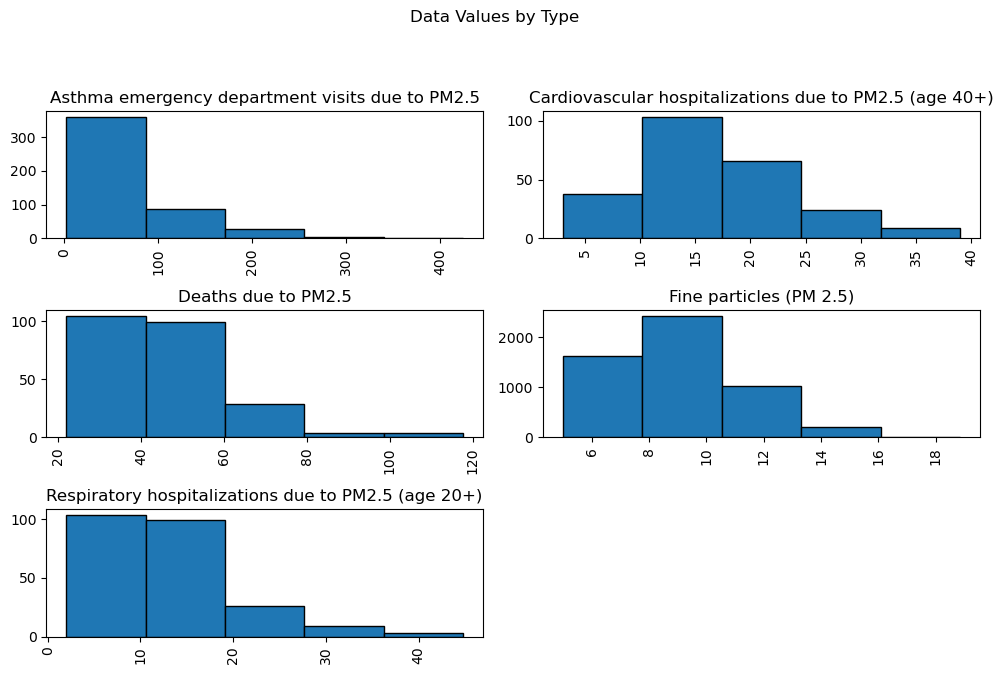

In [14]:
#make histogram to check for outliers 
#y axis is value counts, x is Data Value 
pm25_all.hist(column='Data Value', by='Name', bins=5, edgecolor='black', figsize=(10, 18), layout=(9,2))  
plt.suptitle("Data Values by Type", y=1.02)  
plt.subplots_adjust(hspace=0.8, wspace=0.4) 
plt.tight_layout() 
plt.show() 

In [15]:
#pivot table
asthma_pivot = asthma_df.pivot_table( index=['Geo Place Name', 'Time Period'], columns='Name', values='Data Value' ) 
asthma_pivot.columns = asthma_pivot.columns.str.strip() 
asthma_pivot

Name                               Asthma emergency department visits due to PM2.5
Geo Place Name        Time Period                                                 
Bayside - Little Neck 2005-2007                                          17.600000
                      2009-2011                                          14.400000
                      2012-2014                                          10.031533
                      2015-2017                                           8.550000
                      2017-2019                                           6.000000
...                                                                            ...
Willowbrook           2005-2007                                          23.200000
                      2009-2011                                          24.400000
                      2012-2014                                          21.323009
                      2015-2017                                          15.850000
                      2017-2019                                          14.000000

[240 rows x 1 columns]

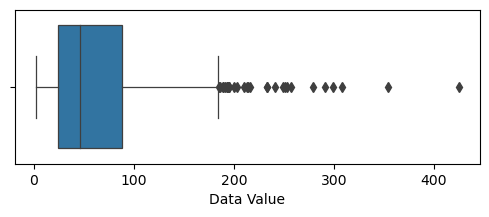

In [16]:
#whisker box plot 

plt.figure(figsize=(6, 2)) 
sns.boxplot(data=asthma_df, x='Data Value', linewidth=0.9) 
plt.show() 

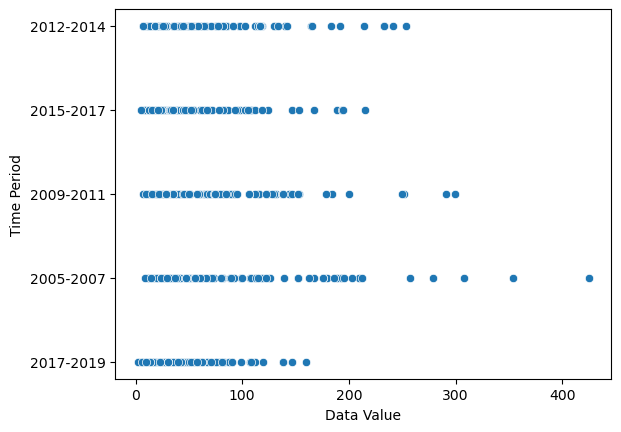

In [17]:
sns.scatterplot(data = asthma_df, x = 'Data Value', 
                y = 'Time Period'); 

In [19]:
#correlation calculation without visuals
correlation_value = asthma_df['Data Value'].corr(pm25_all['Data Value'])
print(correlation_value

SyntaxError: unexpected EOF while parsing (3380819590.py, line 3)

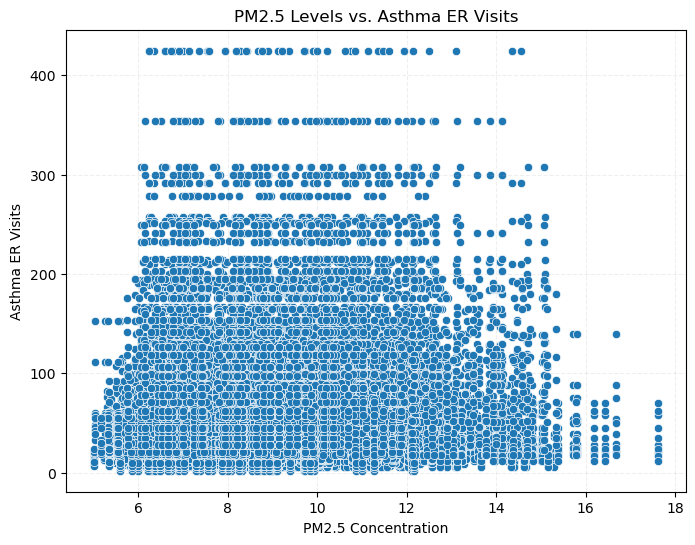

In [20]:
#scatter plot - asthma ER vs pm2.5 levels
#will use these dfs later too
asthma_df2 = asthma_df.rename(columns={"Data Value": "asthma_er_visits"})  
pm_df2 = pm_df.rename(columns={"Data Value": "pm25_levels"})  

merged_df = pd.merge(asthma_df2, pm_df2, on="Geo Place Name")  
plt.figure(figsize=(8, 6)) 
sns.scatterplot(data=merged_df, x="pm25_levels", y="asthma_er_visits") 

plt.title("PM2.5 Levels vs. Asthma ER Visits")  
plt.xlabel("PM2.5 Concentration") 
plt.ylabel("Asthma ER Visits")  
plt.grid(True, linestyle="--", alpha=0.2)  
plt.show() 

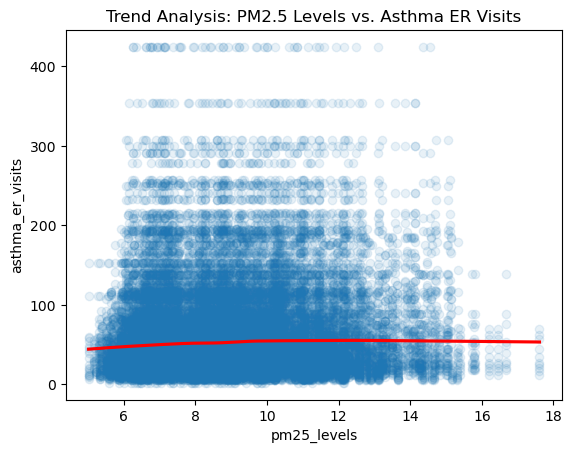

In [21]:
#clean it up so it's readable - though a heat map may be better
sns.regplot(data=merged_df, x='pm25_levels', y='asthma_er_visits', 
            scatter_kws={'alpha': 0.1}, line_kws={'color': 'red'}, lowess=True)
plt.title('Trend Analysis: PM2.5 Levels vs. Asthma ER Visits')
plt.show()

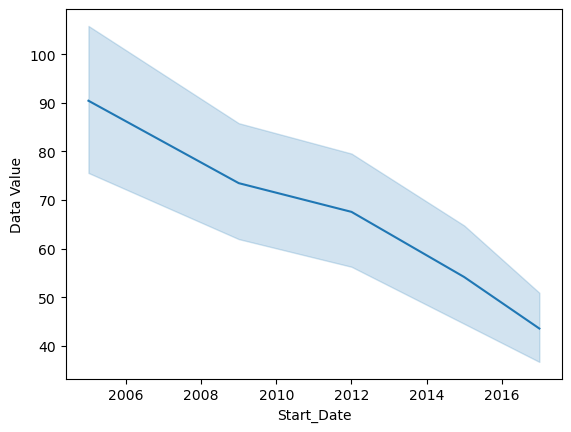

In [22]:
#look at trends over the years
asthma = asthma_df['Start_Date'].dt.year 
sns.lineplot(data = asthma_df, x = "Start_Date", 
       y = 'Data Value', 
       estimator = np.mean); 

In [122]:
#heat map 1

asthma_df2 = asthma_df.rename(columns={"Data Value": "asthma_er_visits"})  
pm_df2 = pm_df.rename(columns={"Data Value": "pm25_levels"})  
cardio_df2=cardio_df.rename(columns={"Data Value": "cardio_levels"})  
death_df2=death_df.rename(columns={"Data Value": "death_levels"})  
resp_df2= resp_df.rename(columns={"Data Value": "resp_levels"})  

merged_df = (
    asthma_df2
    .merge(pm_df2, on="Geo Place Name")
    .merge(cardio_df2, on="Geo Place Name")
    .merge(death_df2, on="Geo Place Name")
    .merge(resp_df2, on="Geo Place Name")
)



columns_to_correlate = ['asthma_er_visits', 'pm25_levels', 'cardio_levels', 'death_levels', 'resp_levels']
corr_matrix = merged_df[columns_to_correlate].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,        
    cmap='seismic',
    linewidths=0.75,       
    linecolor='black',
    cbar=True,
    vmin=-1,
    vmax=1,
    mask=mask
    annot=True,
    annot_kws={'size': 8, 'color': 'black'}
)
annot_kws = {'size': 8, 'color': 'black'} 

plt.tick_params(labelsize = 10, rotation = 45) 
plt.title('Correlation Plot', size = 14); 
plt.show()

SyntaxError: invalid syntax (1162348614.py, line 32)

In [24]:
unique_variables = air_df['Name'].unique()
print(unique_variables)

['Nitrogen dioxide (NO2)' 'Fine particles (PM 2.5)'
 'Boiler Emissions- Total SO2 Emissions' 'Ozone (O3)'
 'Asthma emergency department visits due to PM2.5'
 'Annual vehicle miles traveled'
 'Respiratory hospitalizations due to PM2.5 (age 20+)'
 'Asthma hospitalizations due to Ozone'
 'Boiler Emissions- Total NOx Emissions'
 'Boiler Emissions- Total PM2.5 Emissions'
 'Outdoor Air Toxics - Formaldehyde' 'Outdoor Air Toxics - Benzene'
 'Asthma emergency departments visits due to Ozone'
 'Annual vehicle miles traveled (cars)'
 'Annual vehicle miles traveled (trucks)'
 'Cardiovascular hospitalizations due to PM2.5 (age 40+)'
 'Deaths due to PM2.5' 'Cardiac and respiratory deaths due to Ozone']


In [25]:
#Environmental Pollutants 
no2_df = clean_df[clean_df["Name"] == "Nitrogen dioxide (NO2)"] 
pm25_df = clean_df[clean_df["Name"] == "Fine particles (PM 2.5)"] 
ozone_df = clean_df[clean_df["Name"] == "Ozone (O3)"] 

#Boiler & Industrial Emissions 
so2_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total SO2 Emissions"] 
nox_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total NOx Emissions"] 
pm25_em_df = clean_df[clean_df["Name"] == "Boiler Emissions- Total PM2.5 Emissions"] 

#Outdoor Air Toxics 
form_df = clean_df[clean_df["Name"] == "Outdoor Air Toxics - Formaldehyde"] 
benz_df = clean_df[clean_df["Name"] == "Outdoor Air Toxics - Benzene"] 

#Traffic & Vehicle Metrics 
vmt_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled"] 
vmt_cars_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled (cars)"] 
vmt_trck_df = clean_df[clean_df["Name"] == "Annual vehicle miles traveled (trucks)"] 

#Health: Asthma 
asth_pm_df = clean_df[clean_df["Name"] == "Asthma emergency department visits due to PM2.5"] 
asth_oz_h_df= clean_df[clean_df["Name"] == "Asthma hospitalizations due to Ozone"] 
asth_oz_ed_df= clean_df[clean_df["Name"] == "Asthma emergency departments visits due to Ozone"] 

#Health: everything else
resp_df = clean_df[clean_df["Name"] == "Respiratory hospitalizations due to PM2.5 (age 20+)"] 
cardio_df = clean_df[clean_df["Name"] == "Cardiovascular hospitalizations due to PM2.5 (age 40+)"] 
deaths_pm_df= clean_df[clean_df["Name"] == "Deaths due to PM2.5"] 
deaths_oz_df= clean_df[clean_df["Name"] == "Cardiac and respiratory deaths due to Ozone"] 

In [26]:
pivoted_df = clean_df.pivot_table( index="Geo Place Name", columns="Name", values="Data Value", aggfunc="mean" ) 

name_mapping = { 'Nitrogen dioxide (NO2)': 'NO2 Levels', 'Fine particles (PM 2.5)': 'PM2.5 Levels', 'Boiler Emissions- Total SO2 Emissions': 'Boiler SO2', 'Ozone (O3)': 'Ozone Levels', 'Asthma emergency department visits due to PM2.5': 'Asthma ED (PM2.5)', 'Annual vehicle miles traveled': 'VMT Total', 'Respiratory hospitalizations due to PM2.5 (age 20+)': 'Resp Hosp (PM2.5)', 'Asthma hospitalizations due to Ozone': 'Asthma Hosp (Ozone)', 'Boiler Emissions- Total NOx Emissions': 'Boiler NOx', 'Boiler Emissions- Total PM2.5 Emissions': 'Boiler PM2.5', 'Outdoor Air Toxics - Formaldehyde': 'Formaldehyde', 'Outdoor Air Toxics - Benzene': 'Benzene', 'Asthma emergency departments visits due to Ozone': 'Asthma ED (Ozone)', 'Annual vehicle miles traveled (cars)': 'VMT Cars', 'Annual vehicle miles traveled (trucks)': 'VMT Trucks', 'Cardiovascular hospitalizations due to PM2.5 (age 40+)': 'Cardio Hosp (PM2.5)', 'Deaths due to PM2.5': 'Deaths (PM2.5)', 'Cardiac and respiratory deaths due to Ozone': 'Deaths (Ozone)' } 
pivoted_df = pivoted_df.rename(columns=name_mapping) 

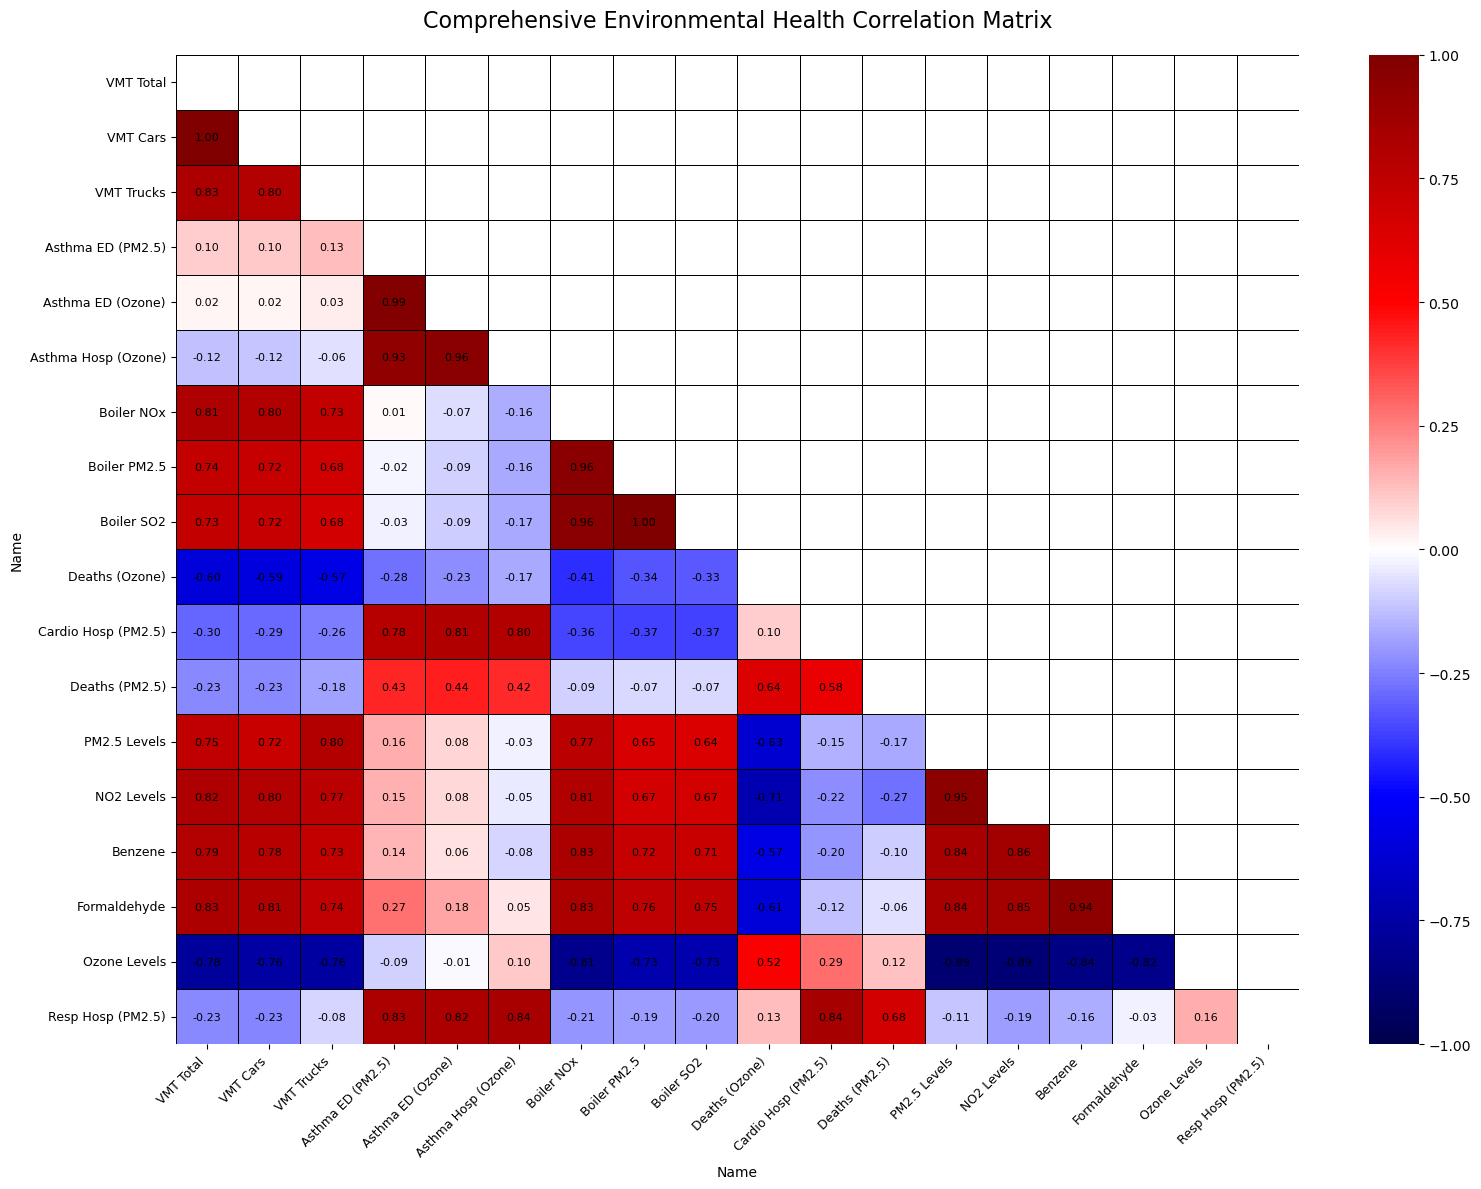

In [27]:
# heat map of envronmental & health variables
corr_matrix = pivoted_df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 12)) 
sns.heatmap( corr_matrix, mask=mask, cmap='seismic', linewidths=0.5, linecolor='black', cbar=True, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={'size': 8, 'color': 'black'} ) 
plt.xticks(rotation=45, ha='right', fontsize=9) 
plt.yticks(rotation=0, fontsize=9) 
plt.title('Comprehensive Environmental Health Correlation Matrix', size=16, pad=20) 
plt.tight_layout() 
plt.show() 

In [66]:
clean_df['Name'] = clean_df['Name'].astype(str).str.strip()

target_labels = [
"Nitrogen dioxide (NO2)",
"Fine particles (PM 2.5)",
"Boiler Emissions- Total SO2 Emissions",
"Ozone (O3)",
"Boiler Emissions- Total NOx Emissions",
"Boiler Emissions- Total PM2.5 Emissions",
"Outdoor Air Toxics - Formaldehyde",
"Outdoor Air Toxics - Benzene",]

neigh_df = clean_df[clean_df["Name"].isin(target_labels)]

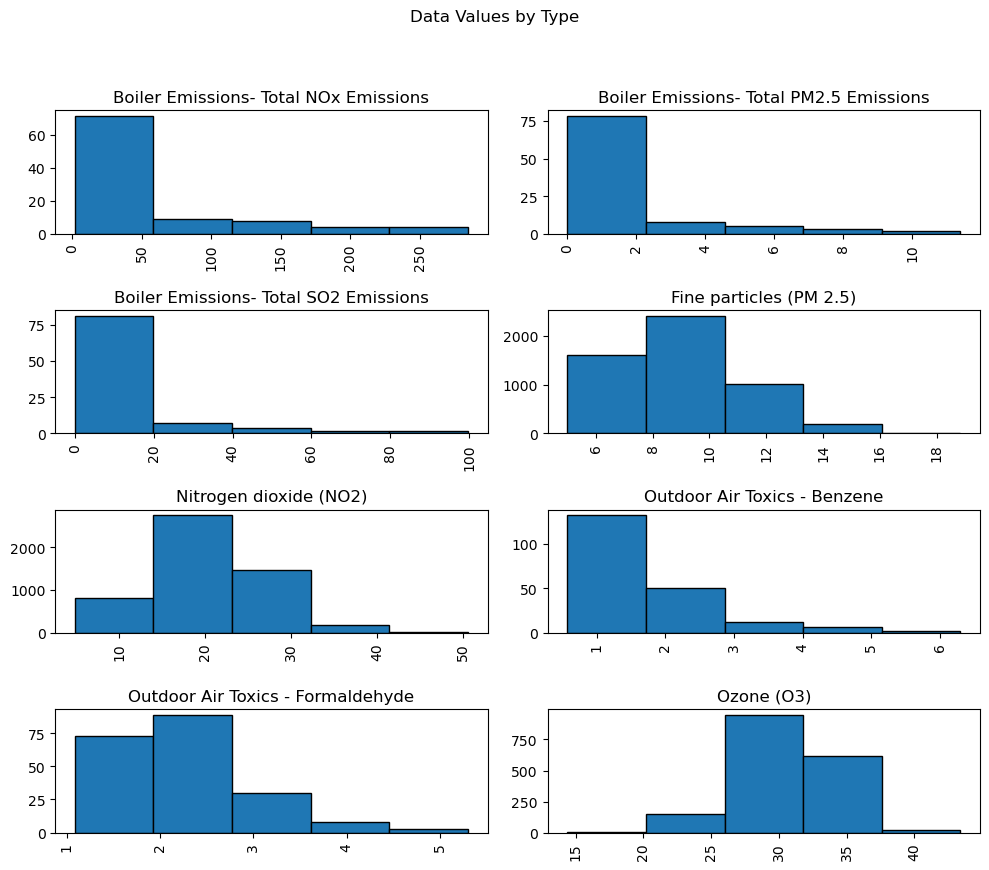

In [67]:
neigh_df.hist(column='Data Value', by='Name', bins=5, edgecolor='black', figsize=(10, 18), layout=(9,2))  
plt.suptitle("Data Values by Type", y=1.02)  
plt.subplots_adjust(hspace=0.8, wspace=0.4) 
plt.tight_layout() 
plt.show() 

In [117]:
col_reference={"Nitrogen dioxide (NO2)":{'low':0 , 'high': 42},
"Fine particles (PM 2.5)":{'low':0 , 'high': 16},
"Boiler Emissions- Total SO2 Emissions":{'low':0 , 'high': 100},
"Ozone (O3)":{'low':10 , 'high': 45},
"Boiler Emissions- Total NOx Emissions":{'low':0 , 'high': 325},
"Boiler Emissions- Total PM2.5 Emissions":{'low':0 , 'high': 14},
"Outdoor Air Toxics - Formaldehyde":{'low':0 , 'high': 6},
"Outdoor Air Toxics - Benzene":{'low':0 , 'high': 5.5},}

In [118]:
ref_df = pd.DataFrame.from_dict(col_reference, orient="index")
ref_df.index.name = "pollutants"
ref_df = ref_df.reset_index()

print(ref_df)

                                pollutants  low   high
0                   Nitrogen dioxide (NO2)    0   42.0
1                  Fine particles (PM 2.5)    0   16.0
2    Boiler Emissions- Total SO2 Emissions    0  100.0
3                               Ozone (O3)   10   45.0
4    Boiler Emissions- Total NOx Emissions    0  325.0
5  Boiler Emissions- Total PM2.5 Emissions    0   14.0
6        Outdoor Air Toxics - Formaldehyde    0    6.0
7             Outdoor Air Toxics - Benzene    0    5.5


In [119]:
ref_lookup = ref_df.set_index("pollutants")

norm_matrix = neigh_matrix.copy()

for col in norm_matrix.columns:
    if col in ref_lookup.index:
        low = ref_lookup.loc[col, "low"]
        high = ref_lookup.loc[col, "high"]
        norm_matrix[col] = (neigh_matrix[col] - low) / (high - low)

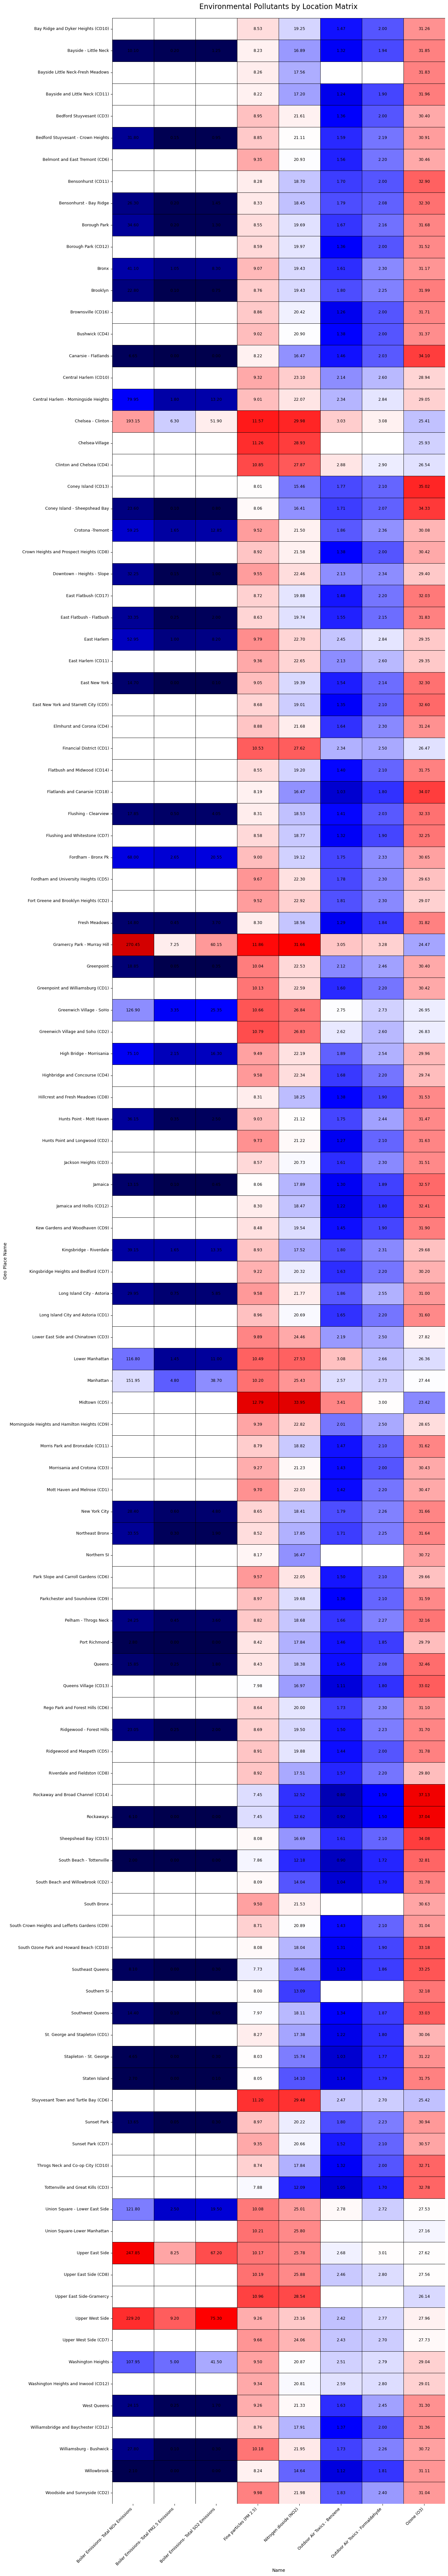

In [121]:
mask = norm_matrix.isnull()
plt.figure(figsize=(14, 80))


sns.heatmap(
    norm_matrix,
    mask=mask,
    cmap="seismic",
    linewidths=0.5,
    linecolor="black",
    vmin=0,
    vmax=1,
    cbar=False,
    fmt=".2f",
    annot_kws={"size": 9, "color": "black"},
    annot=neigh_matrix,
)


plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Environmental Pollutants by Location Matrix", size=16, pad=20)
plt.tight_layout()
plt.show()

In [112]:
#check that the empty boxes aren't an error
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.crosstab(clean_df  
['Name' 
], clean_df  
['Geo Place Name' 
]) 

Geo Place Name,Bay Ridge and Dyker Heights (CD10),Bayside - Little Neck,Bayside Little Neck-Fresh Meadows,Bayside and Little Neck (CD11),Bedford Stuyvesant (CD3),Bedford Stuyvesant - Crown Heights,Belmont and East Tremont (CD6),Bensonhurst (CD11),Bensonhurst - Bay Ridge,Borough Park,Borough Park (CD12),Bronx,Brooklyn,Brownsville (CD16),Bushwick (CD4),Canarsie - Flatlands,Central Harlem (CD10),Central Harlem - Morningside Heights,Chelsea - Clinton,Chelsea-Village,Clinton and Chelsea (CD4),Coney Island (CD13),Coney Island - Sheepshead Bay,Crotona -Tremont,Crown Heights and Prospect Heights (CD8),Downtown - Heights - Slope,East Flatbush (CD17),East Flatbush - Flatbush,East Harlem,East Harlem (CD11),East New York,East New York and Starrett City (CD5),Elmhurst and Corona (CD4),Financial District (CD1),Flatbush and Midwood (CD14),Flatlands and Canarsie (CD18),Flushing - Clearview,Flushing and Whitestone (CD7),Fordham - Bronx Pk,Fordham and University Heights (CD5),Fort Greene and Brooklyn Heights (CD2),Fresh Meadows,Gramercy Park - Murray Hill,Greenpoint,Greenpoint and Williamsburg (CD1),Greenwich Village - SoHo,Greenwich Village and Soho (CD2),High Bridge - Morrisania,Highbridge and Concourse (CD4),Hillcrest and Fresh Meadows (CD8),Hunts Point - Mott Haven,Hunts Point and Longwood (CD2),Jackson Heights (CD3),Jamaica,Jamaica and Hollis (CD12),Kew Gardens and Woodhaven (CD9),Kingsbridge - Riverdale,Kingsbridge Heights and Bedford (CD7),Long Island City - Astoria,Long Island City and Astoria (CD1),Lower East Side and Chinatown (CD3),Lower Manhattan,Manhattan,Midtown (CD5),Morningside Heights and Hamilton Heights (CD9),Morris Park and Bronxdale (CD11),Morrisania and Crotona (CD3),Mott Haven and Melrose (CD1),New York City,Northeast Bronx,Northern SI,Park Slope and Carroll Gardens (CD6),Parkchester and Soundview (CD9),Pelham - Throgs Neck,Port Richmond,Queens,Queens Village (CD13),Rego Park and Forest Hills (CD6),Ridgewood - Forest Hills,Ridgewood and Maspeth (CD5),Riverdale and Fieldston (CD8),Rockaway and Broad Channel (CD14),Rockaways,Sheepshead Bay (CD15),South Beach - Tottenville,South Beach and Willowbrook (CD2),South Bronx,South Crown Heights and Lefferts Gardens (CD9),South Ozone Park and Howard Beach (CD10),Southeast Queens,Southern SI,Southwest Queens,St. George and Stapleton (CD1),Stapleton - St. George,Staten Island,Stuyvesant Town and Turtle Bay (CD6),Sunset Park,Sunset Park (CD7),Throgs Neck and Co-op City (CD10),Tottenville and Great Kills (CD3),Union Square - Lower East Side,Union Square-Lower Manhattan,Upper East Side,Upper East Side (CD8),Upper East Side-Gramercy,Upper West Side,Upper West Side (CD7),Washington Heights,Washington Heights and Inwood (CD12),West Queens,Williamsbridge and Baychester (CD12),Williamsburg - Bushwick,Willowbrook,Woodside and Sunnyside (CD2)
Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Annual vehicle miles traveled,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,0,3,3,3,3,3,3,3,3,3,3,0,3,3,0,3,3,3,3,3,3,3,3,3
Annual vehicle miles traveled (cars),3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,0,3,3,3,3,3,3,3,3,3,3,0,3,3,0,3,3,3,3,3,3,3,3,3
Annual vehicle miles traveled (trucks),3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,0,3,3,3,3,3,3,3,3,3,3,0,3,3,0,3,3,3,3,3,3,3,3,3
Asthma emergency department visits due to PM2.5,0,10,0,0,0,10,0,0,10,10,0,10,10,0,0,10,0,10,10,0,0,0,10,10,0,10,0,10,10,0,10,0,0,0,0,0,10,0,10,0,0,10,10,10,0,10,0,10,0,0,10,0,0,10,0,0,10,0,10,0,0,10,10,0,0,0,0,0,10,10,0,0,0,10,10,10,0,0,10,0,0,0,10,0,10,0,0,0,0,10,

In [126]:
#neighborhoods to further investigate: Chelsea-cinton, grammacy murray hill, upper east side, upper west side
#Need to make line plots for each "Name", making sure to allow viewing of seasons spikes

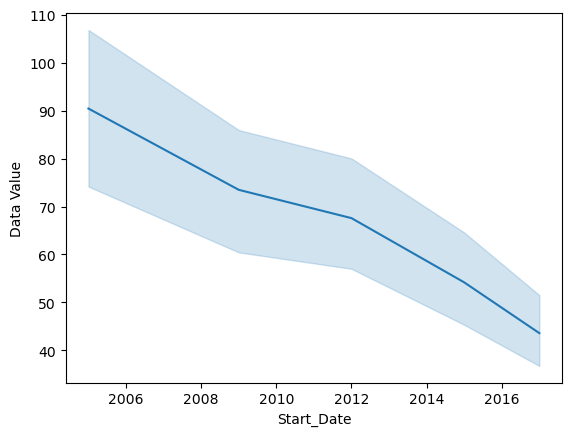

In [97]:
#Chelsea-Clinton = air_df['Start_Date'].dt.year 
#sns.lineplot(data = asthma_df, x = "Start_Date", 
      # y = 'Data Value', 
      # estimator = np.mean); 